# v23 — Simulasi Penuh 2019-2026: v13 (Trend) + BOS/H1 (Breakout Awal) + Skip (Ranging)

**Latar belakang:** v21 & v22 menemukan (di data 2025-2026 saja): (1) v13 murni tetap kuat di
ADX tinggi (PF 2.63 TEST), (2) BOS M5 sendirian gagal (PF<1) krn terlalu banyak breakout palsu,
TAPI **BOS M5 + BOS H1 terjadi BERSAMAAN** menyaring false-positive dgn baik (win rate
36%->54.6%, PF TRAIN 0.58->0.88) -- masalahnya sample cuma 64 trade TRAIN, terlalu kecil utk
dipercaya penuh, (3) semua alternatif strategi ranging (Fibonacci M5, Fibonacci H1, BB squeeze)
GAGAL, skip total tetap pilihan terbaik utk ranging.

**Keputusan user**: jangan filter data supaya "kelihatan bagus" -- simulasikan PENUH 2019-2026
apa adanya, biar rezim rendah (2019-2024, sudah terbukti sulit di v18/v19) kelihatan jujur
dampaknya, bukan disembunyikan. **Origin (v13) dipakai kalau kondisi trend kuat, pendekatan
baru (BOS+H1) dipakai kalau ranging** -- bukan strategi terpisah yg berdiri sendiri, tapi
SATU robot adaptif yg switch logic berdasar regime ADX real-time, persis konsep yg diminta
user dari awal diskusi.

**Logika robot adaptif (v23)**:
1. **ADX >= 25 (trend established)**: mode TREND -- v13 ASLI (v12_score>=9.0 + Order Block
   filter + H1 alignment), TIDAK diubah sama sekali.
2. **18 <= ADX < 25 (zona transisi/awal breakout)**: mode BOS+H1 -- entry HANYA kalau BOS M5
   DAN BOS H1 muncul BERSAMAAN (varian paling menjanjikan dari v22, walau sample kecil di
   2025-2026 -- di sini diuji dgn sample JAUH lebih besar krn 7.6 tahun data).
3. **ADX < 18 (ranging jelas)**: SKIP total -- konsisten dgn semua alternatif ranging yg gagal
   di v20/v21/v22, dan temuan v18/v19 (rezim rendah scr fundamental sulit).

**Evaluasi per TAHUN (bukan cuma agregat)** -- supaya kelihatan jujur apakah adaptasi ini benar2
membantu di tahun-tahun rezim rendah (2019-2024), atau cuma "menambal" tanpa efek nyata.

**TIDAK ADA perubahan ke `usecase.py`** -- murni riset backtest. Kalau hasil ini tervalidasi
kuat, baru didiskusikan terpisah sblm diterapkan ke kode live.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STRATEGY_NAME = "m5_scalping"
VERSION = "v23"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
(PROCESSED_DIR / VERSION).mkdir(parents=True, exist_ok=True)

INITIAL_EQUITY = 100.0
RISK_PCT = 0.01
CONTRACT_SIZE = 100.0
MIN_LOT = 0.01
LOT_STEP = 0.01
REAL_SPREAD = 1.82

MIN_SAMPLE_TRAIN = 30
MIN_SAMPLE_TEST = 15

pd.set_option("display.width", 180)
plt.rcParams["figure.figsize"] = (14, 5)

## 1. Scoring PENUH 2019-2026 (v12_score + Order Block + BOS M5/H1 + H1 EMA) -- cache besar

In [2]:
FULL_CACHE_PATH = PROCESSED_DIR / VERSION / "df_2019_2026_full_mtf.parquet"

if FULL_CACHE_PATH.exists():
    print(f"Load dari cache: {FULL_CACHE_PATH}")
    df = pd.read_parquet(FULL_CACHE_PATH)
else:
    print("Belum ada cache -- scoring v12 PENUH 2019-2026 (518K candle, ini akan makan waktu ~80-100s)...")
    import time as _time
    from app.utils.signals.scoring_v12 import score_de_redundant

    df_m5 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
    df_m5["datetime"] = pd.to_datetime(df_m5["datetime"])
    df_m5 = df_m5.sort_values("datetime").reset_index(drop=True)

    df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
    df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
    df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

    df_h1_shifted = df_h1.copy()
    df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
    h1_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
    df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_cols]].rename(columns={c: f"h1_{c}" for c in h1_cols})

    df_merged = pd.merge_asof(
        df_m5.sort_values("datetime"), df_h1_shifted.sort_values("h1_available_at"),
        left_on="datetime", right_on="h1_available_at", direction="backward",
    )
    print(f"Dataset 2019-2026 merged M5+H1: {len(df_merged)} baris")

    t0 = _time.time()
    scores = np.full(len(df_merged), np.nan)
    for pos in range(len(df_merged)):
        row = df_merged.iloc[pos]
        score, _breakdown = score_de_redundant(row)
        scores[pos] = score
        if pos % 50_000 == 0:
            print(f"  progress: {pos}/{len(df_merged)} ({_time.time()-t0:.0f}s)")

    df_merged["v12_score"] = scores
    print(f"Scoring selesai dalam {_time.time()-t0:.0f}s")

    keep_cols = [
        "datetime", "open", "high", "low", "close", "adx", "atr", "v12_score",
        "bull_chain", "bear_chain", "bos_bull", "bos_bear",
        "ob_bull", "ob_bear", "h1_ob_bull", "h1_ob_bear",
        "h1_ema_50", "h1_ema_200", "h1_bos_bull", "h1_bos_bear",
    ]
    keep_cols = [c for c in keep_cols if c in df_merged.columns]
    df = df_merged[keep_cols].copy()
    df.to_parquet(FULL_CACHE_PATH, index=False)
    print(f"Tersimpan ke cache: {FULL_CACHE_PATH}")

df["year"] = df["datetime"].dt.year
print(f"\nTotal candle: {len(df)}, {df['datetime'].min()} -> {df['datetime'].max()}")
print(df.groupby("year").size())

Belum ada cache -- scoring v12 PENUH 2019-2026 (518K candle, ini akan makan waktu ~80-100s)...


Dataset 2019-2026 merged M5+H1: 518403 baris
  progress: 0/518403 (0s)


  progress: 50000/518403 (8s)


  progress: 100000/518403 (16s)


  progress: 150000/518403 (24s)


...

  progress: 400000/518403 (64s)


  progress: 450000/518403 (73s)


  progress: 500000/518403 (81s)


Scoring selesai dalam 84s


Tersimpan ke cache: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v23\df_2019_2026_full_mtf.parquet

Total candle: 518403, 2019-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00
year
2019    69491
2020    70854
2021    70338
2022    70940
2023    69513
2024    59931
2025    65971
2026    41365
dtype: int64


## 2. Backtest engine adaptif: TREND (v13 asli) / BOS+H1 (transisi) / SKIP (ranging)

In [3]:
def check_h1_alignment_v23(h1_ema_50, h1_ema_200, direction: str) -> bool:
    if h1_ema_50 is None or h1_ema_200 is None or not np.isfinite(h1_ema_50) or not np.isfinite(h1_ema_200):
        return True
    h1_trend = "UP" if h1_ema_50 > h1_ema_200 else ("DOWN" if h1_ema_50 < h1_ema_200 else "FLAT")
    if direction == "BUY" and h1_trend == "DOWN":
        return False
    if direction == "SELL" and h1_trend == "UP":
        return False
    return True


def run_backtest_v23(
    df_signals: pd.DataFrame,
    adx_trend_min: float = 25.0,
    adx_ranging_max: float = 18.0,
    min_signal_score: float = 9.0,
    sl_mult_trend: float = 2.0,
    tp_mult_trend: float = 4.0,
    sl_mult_bos: float = 2.0,
    tp_mult_bos: float = 3.0,
    max_hold: int = 12,
    enable_bos_transition: bool = True,
    require_ob_filter: bool = True,
    require_h1_alignment: bool = True,
    spread_points: float = REAL_SPREAD,
) -> pd.DataFrame:
    close_arr = df_signals["close"].to_numpy()
    high_arr = df_signals["high"].to_numpy()
    low_arr = df_signals["low"].to_numpy()
    adx_arr = df_signals["adx"].to_numpy()
    atr_arr = df_signals["atr"].to_numpy()
    score_arr = df_signals["v12_score"].to_numpy()
    bos_bull_arr = df_signals["bos_bull"].to_numpy()
    bos_bear_arr = df_signals["bos_bear"].to_numpy()
    h1_bos_bull_arr = df_signals["h1_bos_bull"].to_numpy()
    h1_bos_bear_arr = df_signals["h1_bos_bear"].to_numpy()
    ob_bull_arr = df_signals["ob_bull"].to_numpy()
    ob_bear_arr = df_signals["ob_bear"].to_numpy()
    h1_ob_bull_arr = df_signals["h1_ob_bull"].to_numpy()
    h1_ob_bear_arr = df_signals["h1_ob_bear"].to_numpy()
    h1_ema_50_arr = df_signals["h1_ema_50"].to_numpy()
    h1_ema_200_arr = df_signals["h1_ema_200"].to_numpy()
    datetime_arr = df_signals["datetime"].to_numpy()
    n = len(df_signals)

    trades = []
    equity = INITIAL_EQUITY
    i = 0
    while i < n:
        adx, atr, close, score = adx_arr[i], atr_arr[i], close_arr[i], score_arr[i]
        if not np.isfinite(atr) or atr <= 0 or not np.isfinite(adx) or not np.isfinite(score):
            i += 1
            continue

        direction = None
        mode = None
        sl_mult = tp_mult = None

        if adx >= adx_trend_min:
            if score >= min_signal_score:
                direction = "BUY"
            elif score <= -min_signal_score:
                direction = "SELL"
            if direction is not None:
                if require_ob_filter:
                    opposing_ob = (
                        (direction == "BUY" and (ob_bear_arr[i] > 0 or h1_ob_bear_arr[i] > 0)) or
                        (direction == "SELL" and (ob_bull_arr[i] > 0 or h1_ob_bull_arr[i] > 0))
                    )
                    if opposing_ob:
                        direction = None
                if direction is not None and require_h1_alignment:
                    if not check_h1_alignment_v23(h1_ema_50_arr[i], h1_ema_200_arr[i], direction):
                        direction = None
            mode = "TREND"
            sl_mult, tp_mult = sl_mult_trend, tp_mult_trend

        elif adx_ranging_max <= adx < adx_trend_min and enable_bos_transition:
            if bos_bull_arr[i] == 1 and h1_bos_bull_arr[i] == 1:
                direction, mode = "BUY", "BOS_H1"
            elif bos_bear_arr[i] == 1 and h1_bos_bear_arr[i] == 1:
                direction, mode = "SELL", "BOS_H1"
            sl_mult, tp_mult = sl_mult_bos, tp_mult_bos
        # ADX < adx_ranging_max -> SKIP total (tidak ada cabang, direction tetap None)

        if direction is None:
            i += 1
            continue

        sl_points = sl_mult * atr
        tp_points = tp_mult * atr
        entry_price = close + (spread_points if direction == "BUY" else -spread_points)
        tp_price = entry_price + tp_points if direction == "BUY" else entry_price - tp_points
        sl_price = entry_price - sl_points if direction == "BUY" else entry_price + sl_points

        entry_time = datetime_arr[i]
        exit_price = None
        exit_idx = min(i + max_hold, n - 1)
        window_end = min(i + 1 + max_hold, n)
        for candle_idx in range(i + 1, window_end):
            c_high, c_low = high_arr[candle_idx], low_arr[candle_idx]
            hit_tp = c_high >= tp_price if direction == "BUY" else c_low <= tp_price
            hit_sl = c_low <= sl_price if direction == "BUY" else c_high >= sl_price
            if hit_sl:
                exit_price, exit_time = sl_price, datetime_arr[candle_idx]
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time = tp_price, datetime_arr[candle_idx]
                exit_idx = candle_idx
                break
        if exit_price is None:
            exit_price, exit_time = close_arr[exit_idx], datetime_arr[exit_idx]

        next_i = exit_idx + 1
        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        risk_amount = equity * RISK_PCT
        lot = max(round(math.floor((risk_amount / (sl_points * CONTRACT_SIZE)) / LOT_STEP) * LOT_STEP, 2), MIN_LOT) if sl_points > 0 else MIN_LOT
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        trades.append({
            "entry_time": entry_time, "mode": mode, "direction": direction, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS", "equity_after": equity,
        })
        i = next_i

    return pd.DataFrame(trades)


def evaluate(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0, "win_rate_pct": 0, "profit_factor": 0, "net_pnl": 0, "max_drawdown_pct": 0}
    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100
    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
    }


def evaluate_by_mode(trades: pd.DataFrame) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame()
    rows = []
    for mode, g in trades.groupby("mode"):
        wins = (g["result"] == "WIN").sum()
        gp = g.loc[g["pnl"] > 0, "pnl"].sum()
        gl = abs(g.loc[g["pnl"] <= 0, "pnl"].sum())
        rows.append({
            "mode": mode, "n": len(g), "win_rate_pct": round(wins / len(g) * 100, 1),
            "pf": round(gp / gl, 2) if gl > 0 else float("inf"), "net_pnl": round(g["pnl"].sum(), 2),
        })
    return pd.DataFrame(rows)

print("Backtest engine v23 (adaptif TREND/BOS_H1/SKIP) siap.")

Backtest engine v23 (adaptif TREND/BOS_H1/SKIP) siap.


## 3. Simulasi PENUH 2019-2026: v13 murni vs v23 adaptif (v13 + BOS_H1 transisi)

In [4]:
print("=== v13 MURNI (baseline, enable_bos_transition=False) -- seluruh 2019-2026 ===")
trades_v13_full = run_backtest_v23(df, enable_bos_transition=False)
print(evaluate(trades_v13_full, INITIAL_EQUITY))

print("\n=== v23 ADAPTIF (v13 + BOS_H1 transisi) -- seluruh 2019-2026 ===")
trades_v23_full = run_backtest_v23(df, enable_bos_transition=True)
print(evaluate(trades_v23_full, INITIAL_EQUITY))
print(evaluate_by_mode(trades_v23_full).to_string(index=False))

=== v13 MURNI (baseline, enable_bos_transition=False) -- seluruh 2019-2026 ===


{'total_trades': 2107, 'win_rate_pct': 27.01, 'profit_factor': np.float64(0.95), 'net_pnl': np.float64(-216.33), 'max_drawdown_pct': np.float64(-1462.09)}

=== v23 ADAPTIF (v13 + BOS_H1 transisi) -- seluruh 2019-2026 ===


{'total_trades': 2361, 'win_rate_pct': 26.39, 'profit_factor': np.float64(0.88), 'net_pnl': np.float64(-597.43), 'max_drawdown_pct': np.float64(-1838.14)}
  mode    n  win_rate_pct   pf  net_pnl
BOS_H1  277          22.4 0.52  -390.97
 TREND 2084          26.9 0.95  -206.46


## 4. Breakdown PER TAHUN -- jujur, tidak difilter, terutama lihat 2019-2024 (rezim rendah)

In [5]:
def yearly_breakdown(trades: pd.DataFrame, label: str) -> pd.DataFrame:
    trades = trades.copy()
    trades["year"] = pd.to_datetime(trades["entry_time"]).dt.year
    rows = []
    for year, g in trades.groupby("year"):
        m = evaluate(g, INITIAL_EQUITY)
        rows.append({"year": year, "strategy": label, **m})
    return pd.DataFrame(rows)

yearly_v13 = yearly_breakdown(trades_v13_full, "v13_murni")
yearly_v23 = yearly_breakdown(trades_v23_full, "v23_adaptif")

yearly_compare = pd.concat([yearly_v13, yearly_v23]).sort_values(["year", "strategy"])
print("=== Perbandingan per tahun: v13 murni vs v23 adaptif ===")
print(yearly_compare[["year", "strategy", "total_trades", "win_rate_pct", "profit_factor", "net_pnl"]].to_string(index=False))

print("\n=== Breakdown mode per tahun (v23 adaptif -- lihat kontribusi TREND vs BOS_H1 tiap tahun) ===")
trades_v23_full["year"] = pd.to_datetime(trades_v23_full["entry_time"]).dt.year
for year, g in trades_v23_full.groupby("year"):
    print(f"\n--- {year} ---")
    print(evaluate_by_mode(g).to_string(index=False))

=== Perbandingan per tahun: v13 murni vs v23 adaptif ===
 year    strategy  total_trades  win_rate_pct  profit_factor  net_pnl
 2019   v13_murni           322          3.11           0.07  -415.88
 2019 v23_adaptif           344          2.91           0.06  -445.75
 2020   v13_murni           244         28.69           0.64  -163.18
 2020 v23_adaptif           284         27.46           0.56  -246.08
 2021   v13_murni           260         21.15           0.57  -185.33
 2021 v23_adaptif           291         19.24           0.49  -262.55
 2022   v13_murni           294         23.47           0.50  -253.27
 2022 v23_adaptif           327         22.32           0.46  -319.14
 2023   v13_murni           311         18.65           0.47  -274.21
 2023 v23_adaptif           353         18.13           0.44  -348.06
 2024   v13_murni           237         31.65           0.74  -122.05
 2024 v23_adaptif           260         31.92           0.77  -118.43
 2025   v13_murni           276  

## 5. Visualisasi: net PnL per tahun, v13 murni vs v23 adaptif

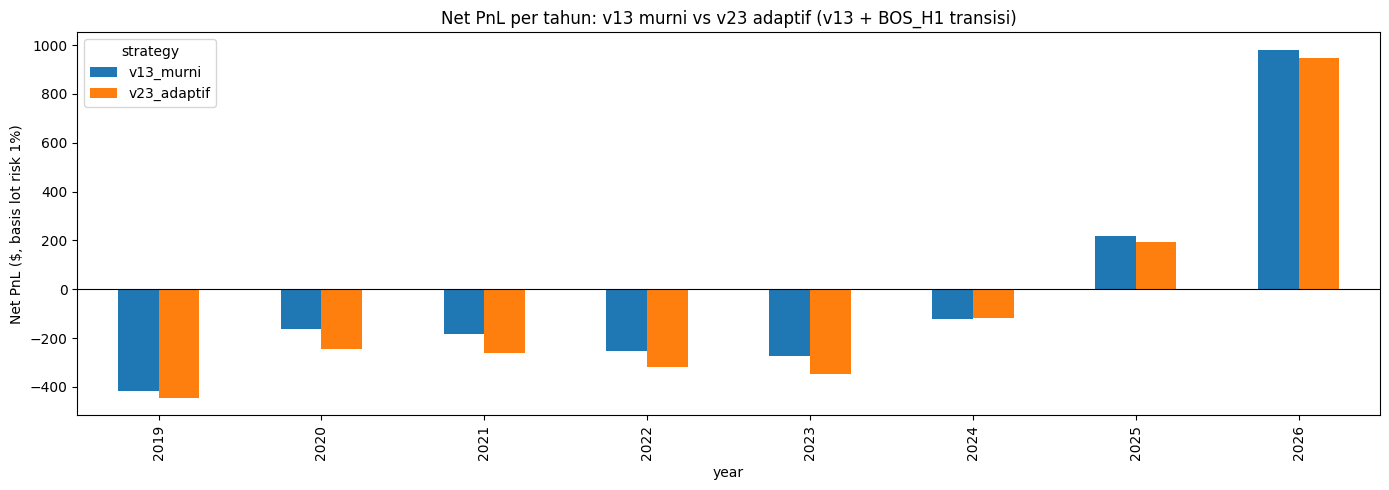

In [6]:
pivot = yearly_compare.pivot(index="year", columns="strategy", values="net_pnl")
ax = pivot.plot(kind="bar", figsize=(14, 5))
ax.set_title("Net PnL per tahun: v13 murni vs v23 adaptif (v13 + BOS_H1 transisi)")
ax.set_ylabel("Net PnL ($, basis lot risk 1%)")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(EXPORT_DIR / "yearly_comparison.png", dpi=120)
plt.show()

## 6. TRAIN/TEST validasi resmi (2019-2023 TRAIN, 2024 TEST -- di luar window tuning v13 asli)

Section 3-5 di atas itu deskriptif (baca pola apa adanya di seluruh histori). Section ini
validasi lebih ketat: apakah BOS_H1 mode robust kalau threshold dicari di TRAIN lalu diuji di
TEST yang benar2 belum pernah dilihat -- konsisten dgn kriteria kejujuran v19-v22.

In [7]:
TRAIN_END_V23 = pd.Timestamp("2024-01-01", tz="UTC")
df_train_v23 = df[df["datetime"] < TRAIN_END_V23].reset_index(drop=True)
df_test_v23 = df[df["datetime"] >= TRAIN_END_V23].reset_index(drop=True)
print(f"TRAIN (2019-2023): {len(df_train_v23)} candle | TEST (2024-2026): {len(df_test_v23)} candle")

print("\n=== v13 murni ===")
tr_v13_train = run_backtest_v23(df_train_v23, enable_bos_transition=False)
tr_v13_test = run_backtest_v23(df_test_v23, enable_bos_transition=False)
print("TRAIN:", evaluate(tr_v13_train, INITIAL_EQUITY))
print("TEST :", evaluate(tr_v13_test, INITIAL_EQUITY))

print("\n=== v23 adaptif (v13 + BOS_H1) ===")
tr_v23_train = run_backtest_v23(df_train_v23, enable_bos_transition=True)
tr_v23_test = run_backtest_v23(df_test_v23, enable_bos_transition=True)
print("TRAIN:", evaluate(tr_v23_train, INITIAL_EQUITY))
print(evaluate_by_mode(tr_v23_train).to_string(index=False))
print("TEST :", evaluate(tr_v23_test, INITIAL_EQUITY))
print(evaluate_by_mode(tr_v23_test).to_string(index=False))

bos_h1_train = tr_v23_train[tr_v23_train["mode"] == "BOS_H1"]
bos_h1_test = tr_v23_test[tr_v23_test["mode"] == "BOS_H1"]
m_bos_train = evaluate(bos_h1_train, INITIAL_EQUITY)
m_bos_test = evaluate(bos_h1_test, INITIAL_EQUITY)
print(f"\n=== Mode BOS_H1 saja: TRAIN n={m_bos_train['total_trades']} PF={m_bos_train['profit_factor']} "
      f"| TEST n={m_bos_test['total_trades']} PF={m_bos_test['profit_factor']} ===")
if m_bos_train["total_trades"] < MIN_SAMPLE_TRAIN or m_bos_test["total_trades"] < MIN_SAMPLE_TEST:
    print(">>> Sample masih di bawah minimum kejujuran (TRAIN>=30, TEST>=15) -- lihat catatan di kesimpulan.")
elif m_bos_train["profit_factor"] > 1.5 and m_bos_test["profit_factor"] > 1.5:
    print(">>> BOS_H1 LOLOS kriteria di kedua split (PF>1.5) -- valid dipertimbangkan.")
else:
    print(">>> BOS_H1 belum mencapai PF>1.5 di salah satu/kedua split.")

TRAIN (2019-2023): 351136 candle | TEST (2024-2026): 167267 candle

=== v13 murni ===


TRAIN: {'total_trades': 1431, 'win_rate_pct': 18.31, 'profit_factor': np.float64(0.45), 'net_pnl': np.float64(-1291.87), 'max_drawdown_pct': np.float64(-1291.87)}
TEST : {'total_trades': 676, 'win_rate_pct': 45.41, 'profit_factor': np.float64(1.62), 'net_pnl': np.float64(1070.38), 'max_drawdown_pct': np.float64(-158.08)}

=== v23 adaptif (v13 + BOS_H1) ===


TRAIN: {'total_trades': 1599, 'win_rate_pct': 17.57, 'profit_factor': np.float64(0.41), 'net_pnl': np.float64(-1621.57), 'max_drawdown_pct': np.float64(-1621.57)}
  mode    n  win_rate_pct   pf  net_pnl
BOS_H1  175          10.9 0.17  -344.55
 TREND 1424          18.4 0.46 -1277.02
TEST : {'total_trades': 762, 'win_rate_pct': 44.88, 'profit_factor': np.float64(1.49), 'net_pnl': np.float64(1018.98), 'max_drawdown_pct': np.float64(-186.22)}
  mode   n  win_rate_pct   pf  net_pnl
BOS_H1 102          42.2 0.88   -46.42
 TREND 660          45.3 1.64  1065.40

=== Mode BOS_H1 saja: TRAIN n=175 PF=0.17 | TEST n=102 PF=0.88 ===
>>> BOS_H1 belum mencapai PF>1.5 di salah satu/kedua split.


## 7. Kesimpulan

*(diisi setelah lihat hasil eksekusi lengkap Section 3-6 -- placeholder)*